# Project B — Fine-tuned RoBERTa Classifier (v2)

Improvements over v1:
- **RoBERTa-base** backbone (stronger than DistilBERT)
- **Layer-wise learning rate decay (LLRD)** — lower layers get smaller LR to preserve pretrained features
- **Label smoothing** — prevents overconfidence, improves generalization
- **Cosine schedule with warmup** — smoother LR decay than linear
- **Class-weighted loss** — handles Fox/NBC imbalance
- **Mixed precision (fp16)** — faster training
- **Early stopping** — stops when val F1 doesn't improve for N epochs

Expected accuracy: **88–92%**. Runs in ~30 min on T4 GPU.

**Before running:** Runtime → Change runtime type → T4 GPU.

## 0. Setup

In [14]:
!pip install -q transformers datasets accelerate

In [15]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/5190finalproj/5190finalproj')
print('Working directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/5190finalproj/5190finalproj


## 1. Imports & Config

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    roc_auc_score, confusion_matrix, classification_report
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: No GPU found. Switch runtime to T4 GPU.')

PROJECT_ROOT = Path('.').resolve()
DATA_DIR  = PROJECT_ROOT / 'data'
FIG_DIR   = PROJECT_ROOT / 'figures'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
MODEL_NAME      = 'roberta-base'
MAX_LEN         = 128
BATCH_SIZE      = 16          # smaller batch → more gradient updates per epoch
GRAD_ACCUM      = 2           # effective batch = 16 * 2 = 32
EPOCHS          = 12
BASE_LR         = 2e-5        # top transformer layer LR
LLRD_DECAY      = 0.9         # each lower layer gets LR * 0.9
HEAD_LR         = 1e-4        # classification head LR
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.1
LABEL_SMOOTHING = 0.1
PATIENCE        = 3           # early stopping patience

print('Config loaded. Model:', MODEL_NAME)

Device: cuda
Config loaded. Model: roberta-base


## 2. Load Data

In [17]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Fox rate (train): {train_df["label"].mean():.3f}')

X_train, y_train = train_df['headline_clean'].tolist(), train_df['label'].tolist()
X_val,   y_val   = val_df['headline_clean'].tolist(),   val_df['label'].tolist()
X_test,  y_test  = test_df['headline_clean'].tolist(),  test_df['label'].tolist()

# Compute class weights for imbalanced loss
counts    = Counter(y_train)
n_total   = len(y_train)
class_weights = torch.tensor(
    [n_total / (2 * counts[i]) for i in range(2)],
    dtype=torch.float
).to(device)
print(f'Class weights: NBC={class_weights[0]:.3f}, Fox={class_weights[1]:.3f}')

Train: 2647 | Val: 567 | Test: 568
Fox rate (train): 0.529
Class weights: NBC=1.061, Fox=0.945


## 3. Tokenize & Build Dataset

In [18]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HeadlineDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(
            texts,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt',
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx],
        }

train_ds = HeadlineDataset(X_train, y_train)
val_ds   = HeadlineDataset(X_val,   y_val)
test_ds  = HeadlineDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches — train: 166 | val: 36 | test: 36


## 4. Load Model with Layer-wise LR Decay (LLRD)

Bottom transformer layers preserve general language knowledge — they get a smaller LR.
Top layers and the classification head get a larger LR to adapt to the task.

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = model.to(device)

# ── LLRD: assign per-layer learning rates ────────────────────────────────────
# RoBERTa has 12 transformer layers (0–11). Layer 11 = top, Layer 0 = bottom.
def get_llrd_optimizer(model, base_lr, decay, head_lr, weight_decay):
    param_groups = []

    # Classification head — highest LR
    param_groups.append({
        'params': [p for n, p in model.named_parameters() if 'classifier' in n],
        'lr': head_lr,
        'weight_decay': weight_decay,
    })

    # Transformer layers — decaying LR from top to bottom
    num_layers = model.config.num_hidden_layers  # 12 for roberta-base
    for layer_idx in range(num_layers - 1, -1, -1):
        layer_lr = base_lr * (decay ** (num_layers - 1 - layer_idx))
        layer_params = [
            p for n, p in model.named_parameters()
            if f'layer.{layer_idx}.' in n
        ]
        if layer_params:
            param_groups.append({
                'params': layer_params,
                'lr': layer_lr,
                'weight_decay': weight_decay,
            })

    # Embeddings — lowest LR
    param_groups.append({
        'params': [p for n, p in model.named_parameters() if 'embeddings' in n],
        'lr': base_lr * (decay ** num_layers),
        'weight_decay': weight_decay,
    })

    return AdamW(param_groups)


optimizer   = get_llrd_optimizer(model, BASE_LR, LLRD_DECAY, HEAD_LR, WEIGHT_DECAY)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps,
)

# Label smoothing loss with class weights
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
scaler  = GradScaler()  # for fp16

print(f'Model: {MODEL_NAME} | Layers: {model.config.num_hidden_layers}')
print(f'Total steps: {total_steps} | Warmup: {int(WARMUP_RATIO * total_steps)}')
print(f'LR groups: head={HEAD_LR:.0e}, top_layer={BASE_LR:.0e}, bottom_layer={BASE_LR * LLRD_DECAY**12:.2e}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base | Layers: 12
Total steps: 996 | Warmup: 99
LR groups: head=1e-04, top_layer=2e-05, bottom_layer=5.65e-06


/tmp/ipykernel_456/1789458148.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()  # for fp16


## 5. Training Loop with Early Stopping

In [20]:
def eval_loop(loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1]
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


best_val_f1   = 0
patience_ctr  = 0
best_ckpt     = MODEL_DIR / 'roberta_best.pt'
history       = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss   = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM

    avg_loss = total_loss / len(train_loader)

    y_true, y_pred, y_prob = eval_loop(val_loader)
    val_acc = accuracy_score(y_true, y_pred)
    val_f1  = f1_score(y_true, y_pred, average='macro')
    val_mcc = matthews_corrcoef(y_true, y_pred)
    val_auc = roc_auc_score(y_true, y_prob)

    history.append({'epoch': epoch, 'loss': avg_loss, 'val_acc': val_acc,
                    'val_f1': val_f1, 'val_mcc': val_mcc, 'val_auc': val_auc})

    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | '
          f'Val Acc: {val_acc:.4f} | F1: {val_f1:.4f} | MCC: {val_mcc:.4f} | AUC: {val_auc:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), best_ckpt)
        print(f'  -> New best saved (F1={best_val_f1:.4f})')
    else:
        patience_ctr += 1
        print(f'  -> No improvement ({patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print('Training complete.')

/tmp/ipykernel_456/2180105927.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/12 | Loss: 0.6700 | Val Acc: 0.7601 | F1: 0.7579 | MCC: 0.5180 | AUC: 0.8358
  -> New best saved (F1=0.7579)


/tmp/ipykernel_456/2180105927.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/12 | Loss: 0.5082 | Val Acc: 0.8236 | F1: 0.8232 | MCC: 0.6664 | AUC: 0.9198
  -> New best saved (F1=0.8232)


/tmp/ipykernel_456/2180105927.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch 9/12 | Loss: 0.2208 | Val Acc: 0.8219 | F1: 0.8213 | MCC: 0.6646 | AUC: 0.9252
  -> No improvement (1/3)


/tmp/ipykernel_456/2180105927.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 10/12 | Loss: 0.2154 | Val Acc: 0.8307 | F1: 0.8305 | MCC: 0.6741 | AUC: 0.9310
  -> No improvement (2/3)


/tmp/ipykernel_456/2180105927.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 11/12 | Loss: 0.2158 | Val Acc: 0.8360 | F1: 0.8358 | MCC: 0.6843 | AUC: 0.9311
  -> No improvement (3/3)
Early stopping at epoch 11.
Training complete.


## 6. Evaluate Best Model

/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  RoBERTa-base fine-tuned  [val]
  Accuracy : 0.8536
  Macro-F1 : 0.8536
  MCC      : 0.7130
  ROC-AUC  : 0.9374
              precision    recall  f1-score   support

         NBC       0.81      0.91      0.85       267
     FoxNews       0.91      0.81      0.85       300

    accuracy                           0.85       567
   macro avg       0.86      0.86      0.85       567
weighted avg       0.86      0.85      0.85       567



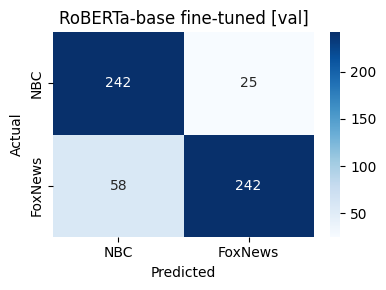

/tmp/ipykernel_456/2180105927.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  RoBERTa-base fine-tuned  [test]
  Accuracy : 0.8592
  Macro-F1 : 0.8591
  MCC      : 0.7203
  ROC-AUC  : 0.9278
              precision    recall  f1-score   support

         NBC       0.83      0.89      0.86       268
     FoxNews       0.89      0.83      0.86       300

    accuracy                           0.86       568
   macro avg       0.86      0.86      0.86       568
weighted avg       0.86      0.86      0.86       568



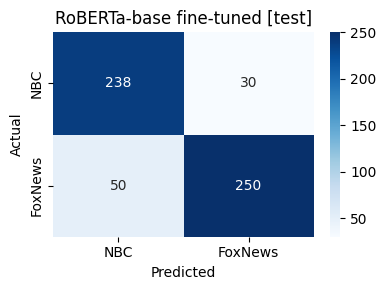

(0.8591549295774648,
 0.8590920367154552,
 np.float64(0.7203187333588752),
 np.float64(0.927792288557214))

In [21]:
model.load_state_dict(torch.load(best_ckpt, map_location=device))

def evaluate(name, loader, split):
    y_true, y_pred, y_prob = eval_loop(loader)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f'\n{"="*52}')
    print(f'  {name}  [{split}]')
    print(f'{"="*52}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro-F1 : {f1:.4f}')
    print(f'  MCC      : {mcc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['NBC', 'FoxNews']))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NBC', 'FoxNews'],
                yticklabels=['NBC', 'FoxNews'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} [{split}]')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'cm_roberta_{split}.png', dpi=120)
    plt.show()
    return acc, f1, mcc, auc

evaluate('RoBERTa-base fine-tuned', val_loader,  'val')
evaluate('RoBERTa-base fine-tuned', test_loader, 'test')

## 7. Training Curve

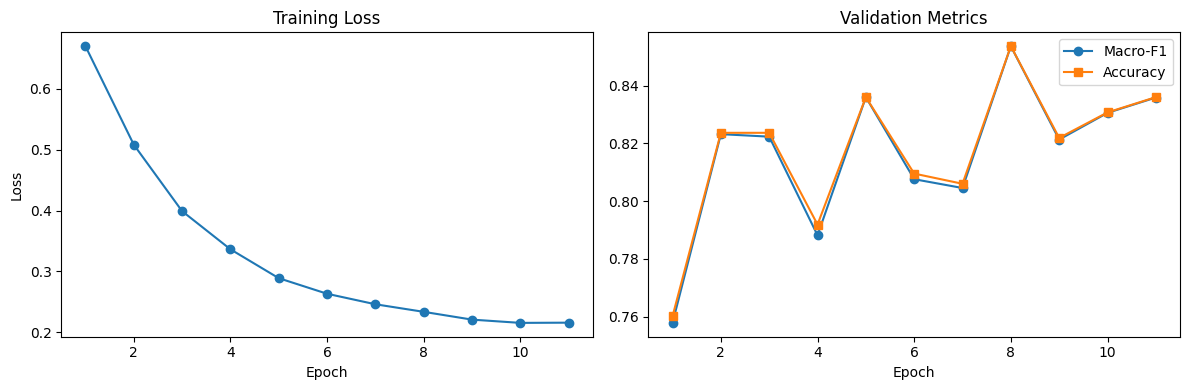

In [22]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['loss'], marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(hist_df['epoch'], hist_df['val_f1'],  marker='o', label='Macro-F1')
axes[1].plot(hist_df['epoch'], hist_df['val_acc'], marker='s', label='Accuracy')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'training_curve_roberta.png', dpi=120)
plt.show()

## 8. Save Final Model for Submission

In [23]:
# Retrain on train + val combined
all_X = X_train + X_val
all_y = y_train + y_val

trainval_ds     = HeadlineDataset(all_X, all_y)
trainval_loader = DataLoader(trainval_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
).to(device)

final_optimizer = get_llrd_optimizer(final_model, BASE_LR, LLRD_DECAY, HEAD_LR, WEIGHT_DECAY)
final_steps     = (len(trainval_loader) // GRAD_ACCUM) * EPOCHS
final_scheduler = get_cosine_schedule_with_warmup(
    final_optimizer,
    num_warmup_steps=int(WARMUP_RATIO * final_steps),
    num_training_steps=final_steps,
)
final_scaler = GradScaler()

for epoch in range(1, EPOCHS + 1):
    final_model.train()
    total_loss = 0
    final_optimizer.zero_grad()
    for step, batch in enumerate(trainval_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        with autocast():
            outputs = final_model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels) / GRAD_ACCUM
        final_scaler.scale(loss).backward()
        if (step + 1) % GRAD_ACCUM == 0:
            final_scaler.unscale_(final_optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
            final_scaler.step(final_optimizer)
            final_scaler.update()
            final_scheduler.step()
            final_optimizer.zero_grad()
        total_loss += loss.item() * GRAD_ACCUM
    print(f'Epoch {epoch}/{EPOCHS} | Loss: {total_loss/len(trainval_loader):.4f}')

torch.save(final_model.state_dict(), MODEL_DIR / 'model.pt')
tokenizer.save_pretrained(str(MODEL_DIR / 'tokenizer'))
print(f'Final model saved to {MODEL_DIR}. Trained on {len(all_X)} examples.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_456/2688534483.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please u

Epoch 1/12 | Loss: 0.6690
Epoch 2/12 | Loss: 0.4995
Epoch 3/12 | Loss: 0.4085
Epoch 4/12 | Loss: 0.3352
Epoch 5/12 | Loss: 0.2946
Epoch 6/12 | Loss: 0.2637
Epoch 7/12 | Loss: 0.2423
Epoch 8/12 | Loss: 0.2264
Epoch 9/12 | Loss: 0.2188
Epoch 10/12 | Loss: 0.2143
Epoch 11/12 | Loss: 0.2105
Epoch 12/12 | Loss: 0.2115
Final model saved to /content/drive/MyDrive/5190finalproj/5190finalproj/models. Trained on 3214 examples.
